# Задача: Скрити цифри

Дадени са числови описания на малки изображения на ръкописни цифри. Всяко изображение е представено чрез 64 признака: стойностите на пикселите в решетка 8 × 8. Стойностите са цели числа от 0 до 16.

Целта е да групирате изображенията в 10 клъстера така, че изображенията на една и съща цифра да попадат в един и същ клъстер. 

## Данни

Файлът `data/digits_public.csv` съдържа:

- `id` — уникален идентификатор на изображение;
- `pixel_00`, ..., `pixel_63` — 64 числови признака.

Брой обекти: 1797  
Брой признаци: 64  
Брой очаквани клъстери: 10

## Вход за модела

Участниците получават само `data/digits_public.csv`.

## Изход / submission формат

Трябва да се подаде CSV файл със следните две колони:

```csv
id,cluster
img_0000,0
img_0001,7
img_0002,7
...
```

Изисквания:

- всеки `id` от входния файл трябва да присъства точно веднъж;
- не трябва да има допълнителни `id` стойности;
- трябва да има точно 10 различни стойности в колоната `cluster`;
- имената на клъстерите нямат значение - например клъстер `3` не е длъжен да означава цифрата 3.

## Автоматична оценка

Официалната метрика е **Adjusted Rand Index** между подадените клъстери и истинските етикети на цифрите.

Оценката ARI е инварианта спрямо номерирането на клъстерите. Това означава, не трябва да отгатвате кое име на клъстер съответства на коя цифра.

## Базово решение 
Базовото решение зарежда публичните данни, прилага PCA до 30 компонента и клъстеризира с K-Means с 10 клъстера. Резултатът се записва в `submission.csv`. 

# Вашата задача 

Можете да настройвате използваните алгоритми или да предложите други методи, за да подобрите базовото решение. 
Не е позволено използването на външни данни. 

In [257]:
import pandas as pd
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import random


df = pd.read_csv("data/digits_public.csv")

seed = 42
random.seed(seed)  # Python random
np.random.seed(seed)  # NumPy random

feature_cols = [c for c in df.columns if c != "id"]
X = df[feature_cols].to_numpy(dtype=float) / 16

In [258]:
def show_cluster_samples(cluster_id, num_samples = 10):
    examples = X[labels == cluster_id][:10].reshape(-1, 8, 8)
    fig, ax = plt.subplots(2, 5)
    ax = ax.flatten()
    for i, example in enumerate(examples):
        ax[i].imshow(examples[i], cmap='grey')

In [259]:
pca = PCA(n_components=20)
x_pca = pca.fit_transform(X)
pca.explained_variance_ratio_.sum()

np.float64(0.8943031165985262)

c:\Users\grade\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


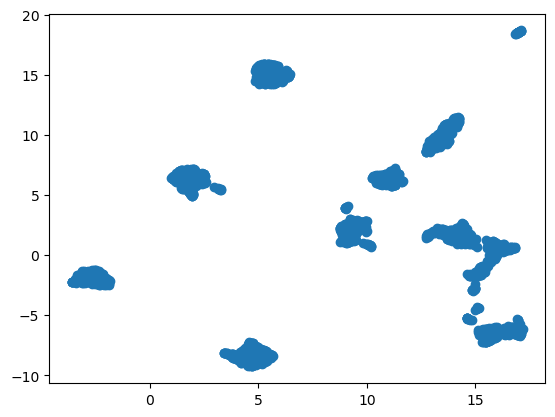

In [ ]:
import umap
_umap = umap.UMAP(n_components=2, random_state=41)
umap_x = _umap.fit_transform(X)
plt.scatter(umap_x[:, 0], umap_x[:, 1])

c:\Users\grade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


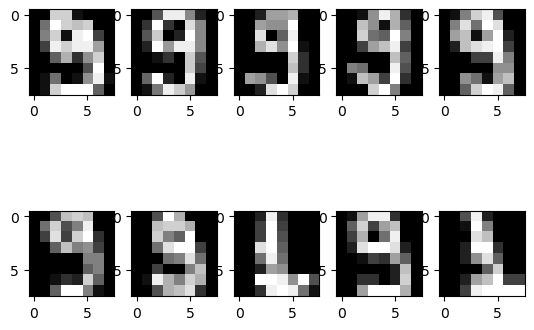

In [261]:
model = KMeans(
        n_clusters=11,
        n_init=20,
        random_state=42,
        algorithm="lloyd",
    )

# model = SpectralClustering(n_clusters=10)

labels = model.fit_predict(umap_x)
counts = np.unique_counts(labels).counts
min_cluster = np.argmin(counts)
counts[min_cluster] = 1e6
second_min_cluster = np.argmin(counts)
# show_cluster_samples(min_cluster)
min_center = model.cluster_centers_[min_cluster]

distances = np.sqrt(np.sum((model.cluster_centers_ - min_cluster) ** 2, axis=1))
distances[min_cluster] = np.inf
closest_cluster_idx = np.argmin(distances)

labels[labels == min_cluster] = second_min_cluster
show_cluster_samples(closest_cluster_idx)

In [262]:
np.unique_counts(labels)

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  9, 10], dtype=int32), counts=array([181, 177, 186, 178, 195, 182, 176, 172, 171, 179]))

In [263]:
# from sklearn.cluster import KMeans
# import numpy as np

# def penalized_kmeans(X, n_clusters, penalty_weight=1.0, max_iter=100):
#     # Initial K-Means clustering
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#     kmeans.fit(X)
#     labels = kmeans.labels_.copy()

#     # Compute initial cluster sizes
#     unique, counts = np.unique(labels, return_counts=True)
#     target_size = len(X) // n_clusters  # Floor division (e.g., 100//10 = 10)

#     for _ in range(max_iter):
#         # Compute penalties (absolute deviation from target size)
#         penalties = np.abs(counts - target_size) * penalty_weight

#         # Reassign points to minimize penalty
#         new_labels = labels.copy()
#         changed = False  # Track if any point was reassigned

#         for i in range(len(X)):
#             # Get distances to all centroids
#             distances = kmeans.transform(X[i].reshape(1, -1))[0]

#             # Adjust distances with penalties
#             adjusted_distances = distances + penalties

#             # Find the best cluster (smallest adjusted distance)
#             best_cluster = np.argmin(adjusted_distances)

#             # Update label if it changes
#             if best_cluster != labels[i]:
#                 new_labels[i] = best_cluster
#                 changed = True

#         # Check convergence (no changes in labels)
#         if not changed:
#             break

#         # Update labels and counts
#         labels = new_labels
#         unique, counts = np.unique(labels, return_counts=True)

#     return labels

# # Example usage
# labels = penalized_kmeans(umap_x[:-4, :], n_clusters=10, penalty_weight=0.5)
# print(np.unique(labels, return_counts=True))

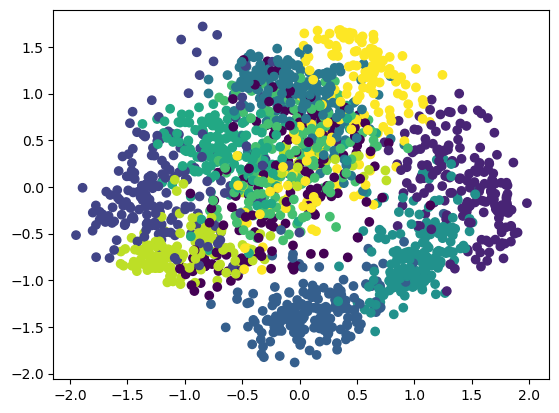

In [264]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels)

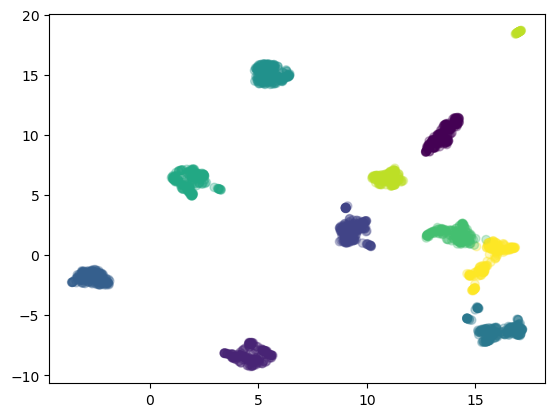

In [265]:
# _umap = umap.UMAP(n_components=2)
# umap_x = _umap.fit_transform(X)
plt.scatter(umap_x[:, 0], umap_x[:, 1], c=labels, alpha=0.3)

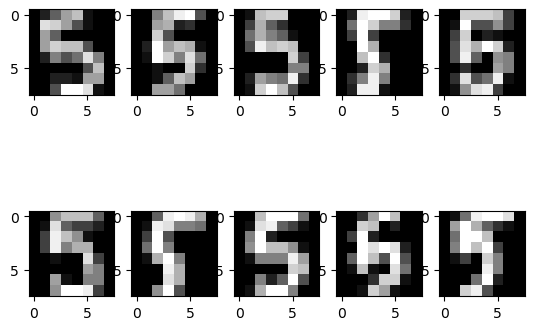

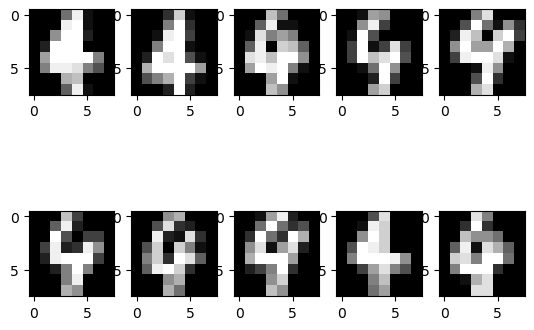

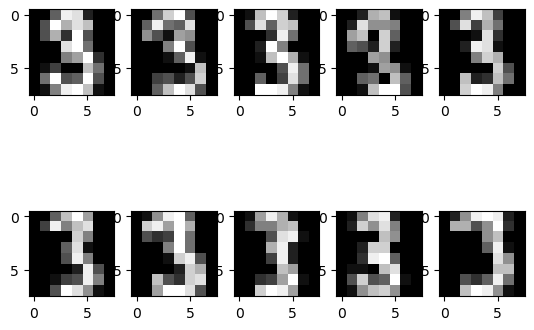

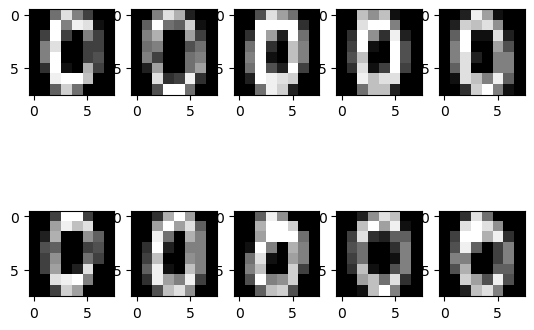

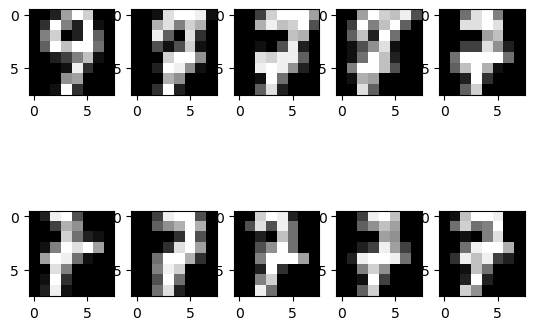

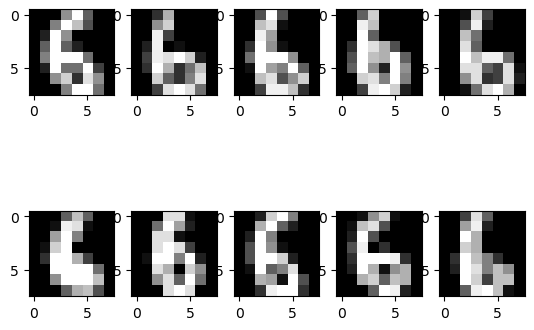

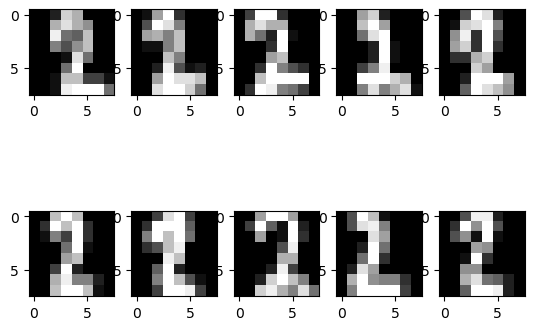

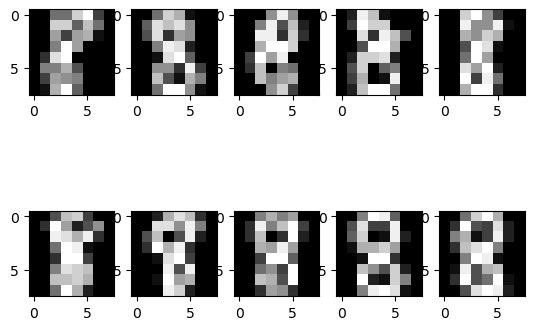

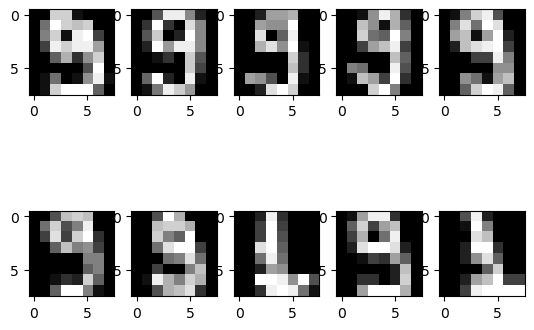

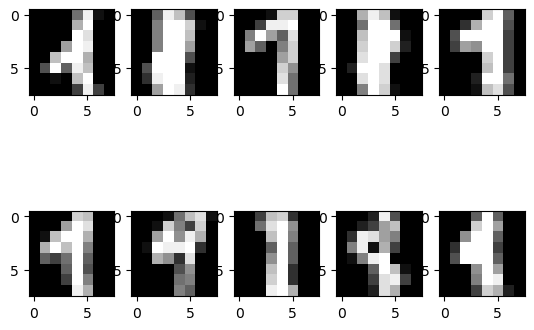

In [266]:
for i in np.unique(labels):
    show_cluster_samples(i)

In [267]:
#UMAP ftw
submission = pd.DataFrame({"id": df["id"], "cluster": labels.astype(int)})
submission.to_csv("submission.csv", index=False)
print(f"Saved {len(submission)} predictions to submission.csv")

Saved 1797 predictions to submission.csv
